<a href="https://colab.research.google.com/github/kimjiwoo2/Pill-agent/blob/develop/notebooks/jiwoo/05_jw_cv_pipeline_test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Set-up
  - GCS 인증 및 프로젝트 설정
  - 라이브러리 import
  - 폰트 설정

In [ ]:
# GCS 인증 및 프로젝트 설정
from google.colab import auth
from google.cloud import storage

auth.authenticate_user()
PROJECT_ID = "pilliot-495707"
!gcloud config set project {PROJECT_ID}

Are you sure you wish to set property [core/project] to pilliot-495707?

Do you want to continue (Y/n)?  y

Updated property [core/project].


In [ ]:
# 라이브러리 import
!pip install pymysql
import os
import io
import glob
import zipfile
import random
import numpy as np
import pandas as pd
import cv2
import gcsfs
import pymysql
from collections import defaultdict
from PIL import Image as PILImage
from IPython.display import Image
import torch
from torchvision import transforms
import warnings
import logging
warnings.filterwarnings('ignore')
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.4/45.4 kB 2.4 MB/s eta 0:00:00


In [ ]:
# 경로 확인
!gcloud storage ls gs://pilliot-raw-data-2026/
!gcloud storage ls gs://pilliot-raw-data-2026/00_original_zip/
!gcloud storage ls gs://pilliot-raw-data-2026/00_original_zip/aihub_576_oral_pill/

gs://pilliot-raw-data-2026/test.txt
gs://pilliot-raw-data-2026/test_wsl.txt
gs://pilliot-raw-data-2026/00_original_zip/
gs://pilliot-raw-data-2026/04_manifests/
gs://pilliot-raw-data-2026/10_training_subsets/
ERROR: (gcloud.storage.ls) HTTPError 403: The billing account for the owning project is disabled in state closed. This command is authenticated as jwioo021213@gmail.com which is the active account specified by the [core/account] property
ERROR: (gcloud.storage.ls) HTTPError 403: The billing account for the owning project is disabled in state closed. This command is authenticated as jwioo021213@gmail.com which is the active account specified by the [core/account] property


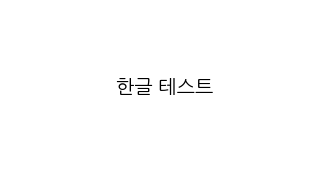

In [ ]:
# 폰트 설정
import subprocess
subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'], capture_output=True)

import matplotlib.font_manager as fm
import matplotlib.pyplot as plt

font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(font_path)
font_prop = fm.FontProperties(fname=font_path, size=14)

fig, ax = plt.subplots(figsize=(4, 2))
ax.text(0.5, 0.5, '한글 테스트',
        ha='center', va='center',
        fontproperties=font_prop)
ax.axis('off')
plt.show()

#CV Pipeline

## 1. 데이터 로드
  - 1.1 Manifest CSV 로드
  - 1.2 zip 기준 샘플링 (조합/단일, train/val)
  - 1.3 GCS zip 스트리밍



In [ ]:
# GCS 파일시스템 연결
fs = gcsfs.GCSFileSystem(project=PROJECT_ID)

# manifest CSV 로드
MANIFEST_PATH = "gs://pilliot-raw-data-2026/04_manifests/detection_manifest_all.csv"

with fs.open(MANIFEST_PATH) as f:
    df = pd.read_csv(f)

print(f"전체 행 수: {len(df)}")
print(df.columns.tolist())
df.head()

OSError: Forbidden: https://storage.googleapis.com/download/storage/v1/b/pilliot-raw-data-2026/o/04_manifests%2Fdetection_manifest_all.csv?alt=media
The billing account for the owning project is disabled in state closed

In [ ]:
def label_zip_to_image_zip_path(label_zip_name):
    # TL → TS, VL → VS 변환
    image_zip_name = label_zip_name.replace("TL_", "TS_").replace("VL_", "VS_")

    # 단일/조합 구분
    if "조합" in label_zip_name:
        dataset_type = "combination"
    else:
        dataset_type = "single"

    # train/validation 구분
    if label_zip_name.startswith("TL_"):
        split = "train"
    else:
        split = "validation"

    gcs_path = f"gs://pilliot-raw-data-2026/00_original_zip/aihub_576_oral_pill/{dataset_type}/{split}/images/{image_zip_name}"
    return gcs_path

# 확인
print(label_zip_to_image_zip_path("TL_1_조합.zip"))
print(label_zip_to_image_zip_path("VL_1_단일.zip"))
print(label_zip_to_image_zip_path("TL_1_단일.zip"))

In [ ]:
# 조합 train, 조합 validation, 단일 train, 단일 validation 대표 zip 1개씩
target_zips = ['TL_1_조합.zip', 'VL_1_조합.zip', 'TL_1_단일.zip', 'VL_1_단일.zip']

df_test = df[df['label_zip_name'].isin(target_zips)].reset_index(drop=True)

print(f"전체 행 수: {len(df_test)}")
print(df_test.groupby(['dataset_type', 'split_type']).size())

In [ ]:
# train 480, val 120으로 샘플링
df_train_sample = df_test[df_test['split_type'] == 'train'].groupby('dataset_type').sample(n=200, random_state=42)
df_val_sample = df_test[df_test['split_type'] == 'validation'].groupby('dataset_type').sample(n=100, random_state=42)

df_sample = pd.concat([df_train_sample, df_val_sample]).reset_index(drop=True)

print(f"전체 샘플 수: {len(df_sample)}")
print(df_sample.groupby(['dataset_type', 'split_type']).size())

In [ ]:
# zip 기준 그룹핑
zip_groups = defaultdict(list)
for idx, row in df_sample.iterrows():
    zip_groups[row['label_zip_name']].append((idx, row))

print(f"zip 종류: {list(zip_groups.keys())}")
print(f"zip별 이미지 수: { {k: len(v) for k, v in zip_groups.items()} }")

In [ ]:
# GCS zip 스트리밍으로 메모리에 이미지 로드
client = storage.Client()
images = {}
failed = []

for label_zip_name, rows in zip_groups.items():
    gcs_zip_path = label_zip_to_image_zip_path(label_zip_name)
    bucket_name = "pilliot-raw-data-2026"
    blob_path = gcs_zip_path.replace(f"gs://{bucket_name}/", "")

    bucket = client.bucket(bucket_name)
    blob = bucket.blob(blob_path)

    print(f"\n{label_zip_name} 열기 중...")

    with blob.open("rb") as f:
        with zipfile.ZipFile(f) as zf:
            all_files = {os.path.basename(x): x for x in zf.namelist()}

            for idx, row in rows:
                file_name = row['image_file']
                if file_name not in all_files:
                    failed.append((idx, file_name))
                    continue

                with zf.open(all_files[file_name]) as img_file:
                    img = PILImage.open(io.BytesIO(img_file.read())).convert("RGB")
                    images[idx] = img

    print(f"  완료: {sum(1 for idx, _ in rows if idx in images)}개 로드")

print(f"\n전체 로드 성공: {len(images)}개")
print(f"실패: {len(failed)}개")

In [ ]:
# 로드 결과 확인 및 시각화
print(f"로드 성공: {len(images)}개")
print(f"실패: {len(failed)}개")

# 4장 샘플 시각화
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
sample_indices = list(images.keys())[:4]

for ax, idx in zip(axes, sample_indices):
    row = df_sample.loc[idx]
    ax.imshow(images[idx])
    ax.set_title(f"{row['dataset_type']}\n{row['split_type']}", fontproperties=font_prop, fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# bbox 좌표 검증 (manifest랑 이미지 맞는지 확인)
# 같은 이미지에 대한 모든 bbox 가져와서 다 그리기
import cv2

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
sample_indices = list(images.keys())[:4]

for ax, idx in zip(axes, sample_indices):
    row = df_sample.loc[idx]
    img_np = np.array(images[idx]).copy()

    # 같은 image_file에 해당하는 행 전체 가져오기
    same_img_rows = df[df['image_file'] == row['image_file']]

    for _, r in same_img_rows.iterrows():
        x, y, w, h = int(r['bbox_x']), int(r['bbox_y']), int(r['bbox_w']), int(r['bbox_h'])
        cv2.rectangle(img_np, (x, y), (x+w, y+h), (255, 0, 0), 3)

    ax.imshow(img_np)
    ax.set_title(f"{row['dataset_type']}/{row['split_type']}\nbbox {len(same_img_rows)}개", fontproperties=font_prop, fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.show()

## 2. 1차 전처리
  - 2.1 AWB + Bilateral Filter + 픽셀 정규화
  - 2.2 bbox 검증 시각화

In [ ]:
# 1차 전처리 함수 정의
def apply_awb(img_bgr):
    """오토 화이트 밸런스 (LAB 색공간 기반)"""
    lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    avg_a = np.average(a)
    avg_b = np.average(b)
    a = a - ((avg_a - 128) * (l / 255.0) * 1.1)
    b = b - ((avg_b - 128) * (l / 255.0) * 1.1)
    a = np.clip(a, 0, 255).astype(np.uint8)
    b = np.clip(b, 0, 255).astype(np.uint8)
    lab = cv2.merge([l, a, b])
    return cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)

def apply_bilateral(img_bgr):
    """Bilateral Filter (엣지 보존 노이즈 제거)"""
    return cv2.bilateralFilter(img_bgr, d=5, sigmaColor=30, sigmaSpace=30)

def preprocess_common(pil_img):
    """
    공통 전처리 (학습 & 추론 모두 적용)
    1. RGB → BGR
    2. 오토 화이트 밸런스
    3. Bilateral Filter
    4. 픽셀값 정규화 (0~1)
    리사이즈/패딩은 YOLO 내부 처리
    """
    img = cv2.cvtColor(np.array(pil_img), cv2.COLOR_RGB2BGR)
    img = apply_awb(img)
    img = apply_bilateral(img)
    img = img.astype(np.float32) / 255.0
    return img

def convert_bbox_to_yolo(row):
    """
    manifest bbox → YOLO 포맷 변환
    (좌상단 픽셀 좌표) → (정규화된 중심 좌표)
    """
    img_w, img_h = row['width'], row['height']
    x_center = (row['bbox_x'] + row['bbox_w'] / 2) / img_w
    y_center = (row['bbox_y'] + row['bbox_h'] / 2) / img_h
    w = row['bbox_w'] / img_w
    h = row['bbox_h'] / img_h
    return x_center, y_center, w, h

# 테스트: 1장 확인
sample_idx = list(images.keys())[0]
sample_row = df_sample.loc[sample_idx]
sample_pil = images[sample_idx]

processed = preprocess_common(sample_pil)
bbox_yolo = convert_bbox_to_yolo(sample_row)

print(f"전처리 전 shape: {np.array(sample_pil).shape}")
print(f"전처리 후 shape: {processed.shape}")
print(f"dtype: {processed.dtype}")
print(f"픽셀값 범위: {processed.min():.3f} ~ {processed.max():.3f}")
print(f"YOLO bbox: x_c={bbox_yolo[0]:.4f}, y_c={bbox_yolo[1]:.4f}, w={bbox_yolo[2]:.4f}, h={bbox_yolo[3]:.4f}")

전처리 전 shape: (1280, 976, 3)
전처리 후 shape: (1280, 976, 3)
dtype: float32
픽셀값 범위: 0.224 ~ 1.000
YOLO bbox: x_c=0.7541, y_c=0.6895, w=0.1926, h=0.3820


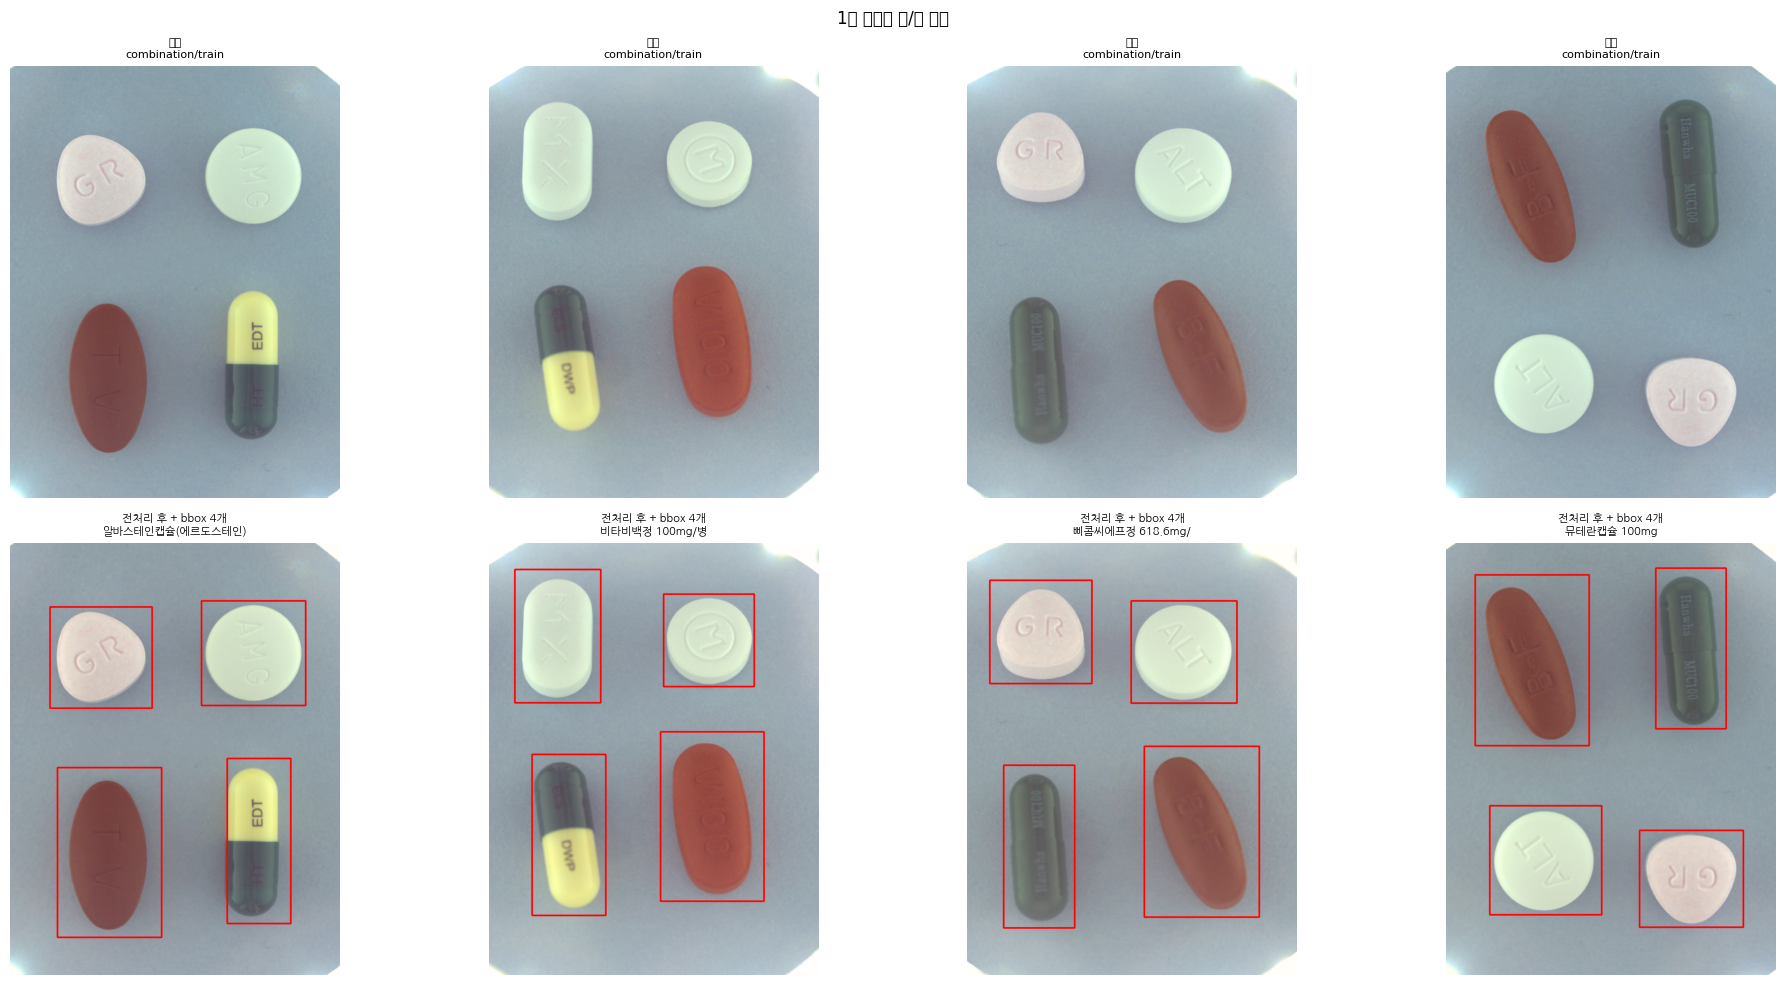

In [ ]:
# 전처리 전/후 시각화 비교
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
sample_indices = list(images.keys())[:4]

for i, idx in enumerate(sample_indices):
    row = df_sample.loc[idx]
    pil_img = images[idx]
    processed = preprocess_common(pil_img)

    # 원본
    axes[0, i].imshow(pil_img)
    axes[0, i].set_title(f"원본\n{row['dataset_type']}/{row['split_type']}", fontsize=8)
    axes[0, i].axis('off')

    # 전처리 후 BGR → RGB 변환
    processed_vis = cv2.cvtColor((processed * 255).astype(np.uint8), cv2.COLOR_BGR2RGB)

    # 같은 이미지 전체 bbox 그리기
    same_img_rows = df[df['image_file'] == row['image_file']]
    for _, r in same_img_rows.iterrows():
        x, y, w, h = int(r['bbox_x']), int(r['bbox_y']), int(r['bbox_w']), int(r['bbox_h'])
        cv2.rectangle(processed_vis, (x, y), (x+w, y+h), (255, 0, 0), 3)

    axes[1, i].imshow(processed_vis)
    axes[1, i].set_title(f"전처리 후 + bbox {len(same_img_rows)}개\n{row['dl_name'][:15]}", fontproperties=font_prop, fontsize=8)
    axes[1, i].axis('off')

plt.suptitle("1차 전처리 전/후 비교", fontsize=12)
plt.tight_layout()
plt.show()

## 3. Detection (YOLOv8n)

  - 3.1 데이터셋 준비
    - 이미지 파일 저장
    - 라벨 txt 파일 생성
    - dataset.yaml 작성
  - 3.2 학습
  - 3.3 추론 결과 확인

In [ ]:
# 디렉토리 생성
os.makedirs("/content/yolo_dataset/images/train", exist_ok=True)
os.makedirs("/content/yolo_dataset/images/validation", exist_ok=True)
os.makedirs("/content/yolo_dataset/labels/train", exist_ok=True)
os.makedirs("/content/yolo_dataset/labels/validation", exist_ok=True)

print("디렉토리 생성 완료")
print(os.listdir("/content/yolo_dataset/images"))

디렉토리 생성 완료
['validation', 'train']


In [ ]:
# 이미지와 라벨 txt 저장
from PIL import Image as PILImage

# 중복 제거
df_sample_dedup = df_sample.drop_duplicates(subset='image_file').reset_index(drop=True)
print(f"중복 제거 후: {len(df_sample_dedup)}개")
print(df_sample_dedup['split_type'].value_counts())

# 이미지 + 라벨 저장
for _, row in df_sample_dedup.iterrows():
    pil_img = images[row.name] if row.name in images else None
    if pil_img is None:
        continue

    split = 'train' if row['split_type'] == 'train' else 'validation'
    file_stem = os.path.splitext(row['image_file'])[0]

    # 1. 전처리 후 이미지 저장
    processed = preprocess_common(pil_img)
    processed_uint8 = (processed * 255).astype(np.uint8)
    processed_rgb = cv2.cvtColor(processed_uint8, cv2.COLOR_BGR2RGB)
    save_img = PILImage.fromarray(processed_rgb)
    save_img.save(f"/content/yolo_dataset/images/{split}/{row['image_file']}")

    # 2. 같은 이미지의 모든 bbox → YOLO 라벨 txt 저장
    same_img_rows = df[df['image_file'] == row['image_file']]
    label_lines = []
    for _, r in same_img_rows.iterrows():
        x_c, y_c, w, h = convert_bbox_to_yolo(r)
        label_lines.append(f"0 {x_c:.6f} {y_c:.6f} {w:.6f} {h:.6f}")

    with open(f"/content/yolo_dataset/labels/{split}/{file_stem}.txt", 'w') as f:
        f.write('\n'.join(label_lines))

print("저장 완료")
print(f"train 이미지: {len(os.listdir('/content/yolo_dataset/images/train'))}장")
print(f"val 이미지: {len(os.listdir('/content/yolo_dataset/images/validation'))}장")
print(f"train 라벨: {len(os.listdir('/content/yolo_dataset/labels/train'))}개")
print(f"val 라벨: {len(os.listdir('/content/yolo_dataset/labels/validation'))}개")

중복 제거 후: 1145개
split_type
train         911
validation    234
Name: count, dtype: int64
저장 완료
train 이미지: 911장
val 이미지: 234장
train 라벨: 911개
val 라벨: 234개


In [ ]:
# YOLO에 넣기 위한 dataset.yaml 작성
import yaml

dataset_config = {
    'path': '/content/yolo_dataset',
    'train': 'images/train',
    'val': 'images/validation',
    'nc': 1,
    'names': ['pill']
}

with open('/content/yolo_dataset/dataset.yaml', 'w') as f:
    yaml.dump(dataset_config, f, default_flow_style=False)

print("dataset.yaml 생성 완료")
with open('/content/yolo_dataset/dataset.yaml', 'r') as f:
    print(f.read())

dataset.yaml 생성 완료
names:
- pill
nc: 1
path: /content/yolo_dataset
train: images/train
val: images/validation



In [ ]:
# YOLOv8 설치 및 학습
# 설치
!pip install ultralytics -q

from ultralytics import YOLO

# YOLOv8n 모델 로드 (pretrained weights로 시작)
model = YOLO('yolov8n.pt')

# 학습
results = model.train(
    data='/content/yolo_dataset/dataset.yaml',
    epochs=20,
    imgsz=640,
    batch=16,
    device=0,
    workers=2,
    project='/content/yolo_runs',
    name='pill_detection',
    patience=5,

    # 반전 금지 (OCR 보존)
    flipud=0.0,
    fliplr=0.0,

    # 조명 변화
    hsv_h=0.015,  # 색조
    hsv_s=0.7,    # 채도
    hsv_v=0.4,    # 명도 (어두운 환경 커버)

    # Mosaic + MixUp
    mosaic=1.0,  # 이미지 4장을 하나로 합침 (1.0: 항상)
    mixup=0.1,   # 이미지 2장 혼합 (0.1: 가끔만 적용)

    # 블러 + Occlusion
    # blur=0.01,   # 가벼운 블러
    erasing=0.4, # 이미지 일부 랜덤 제거
)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 26.2 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolo_dataset/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.0, flipud=0.0, format=torchscri

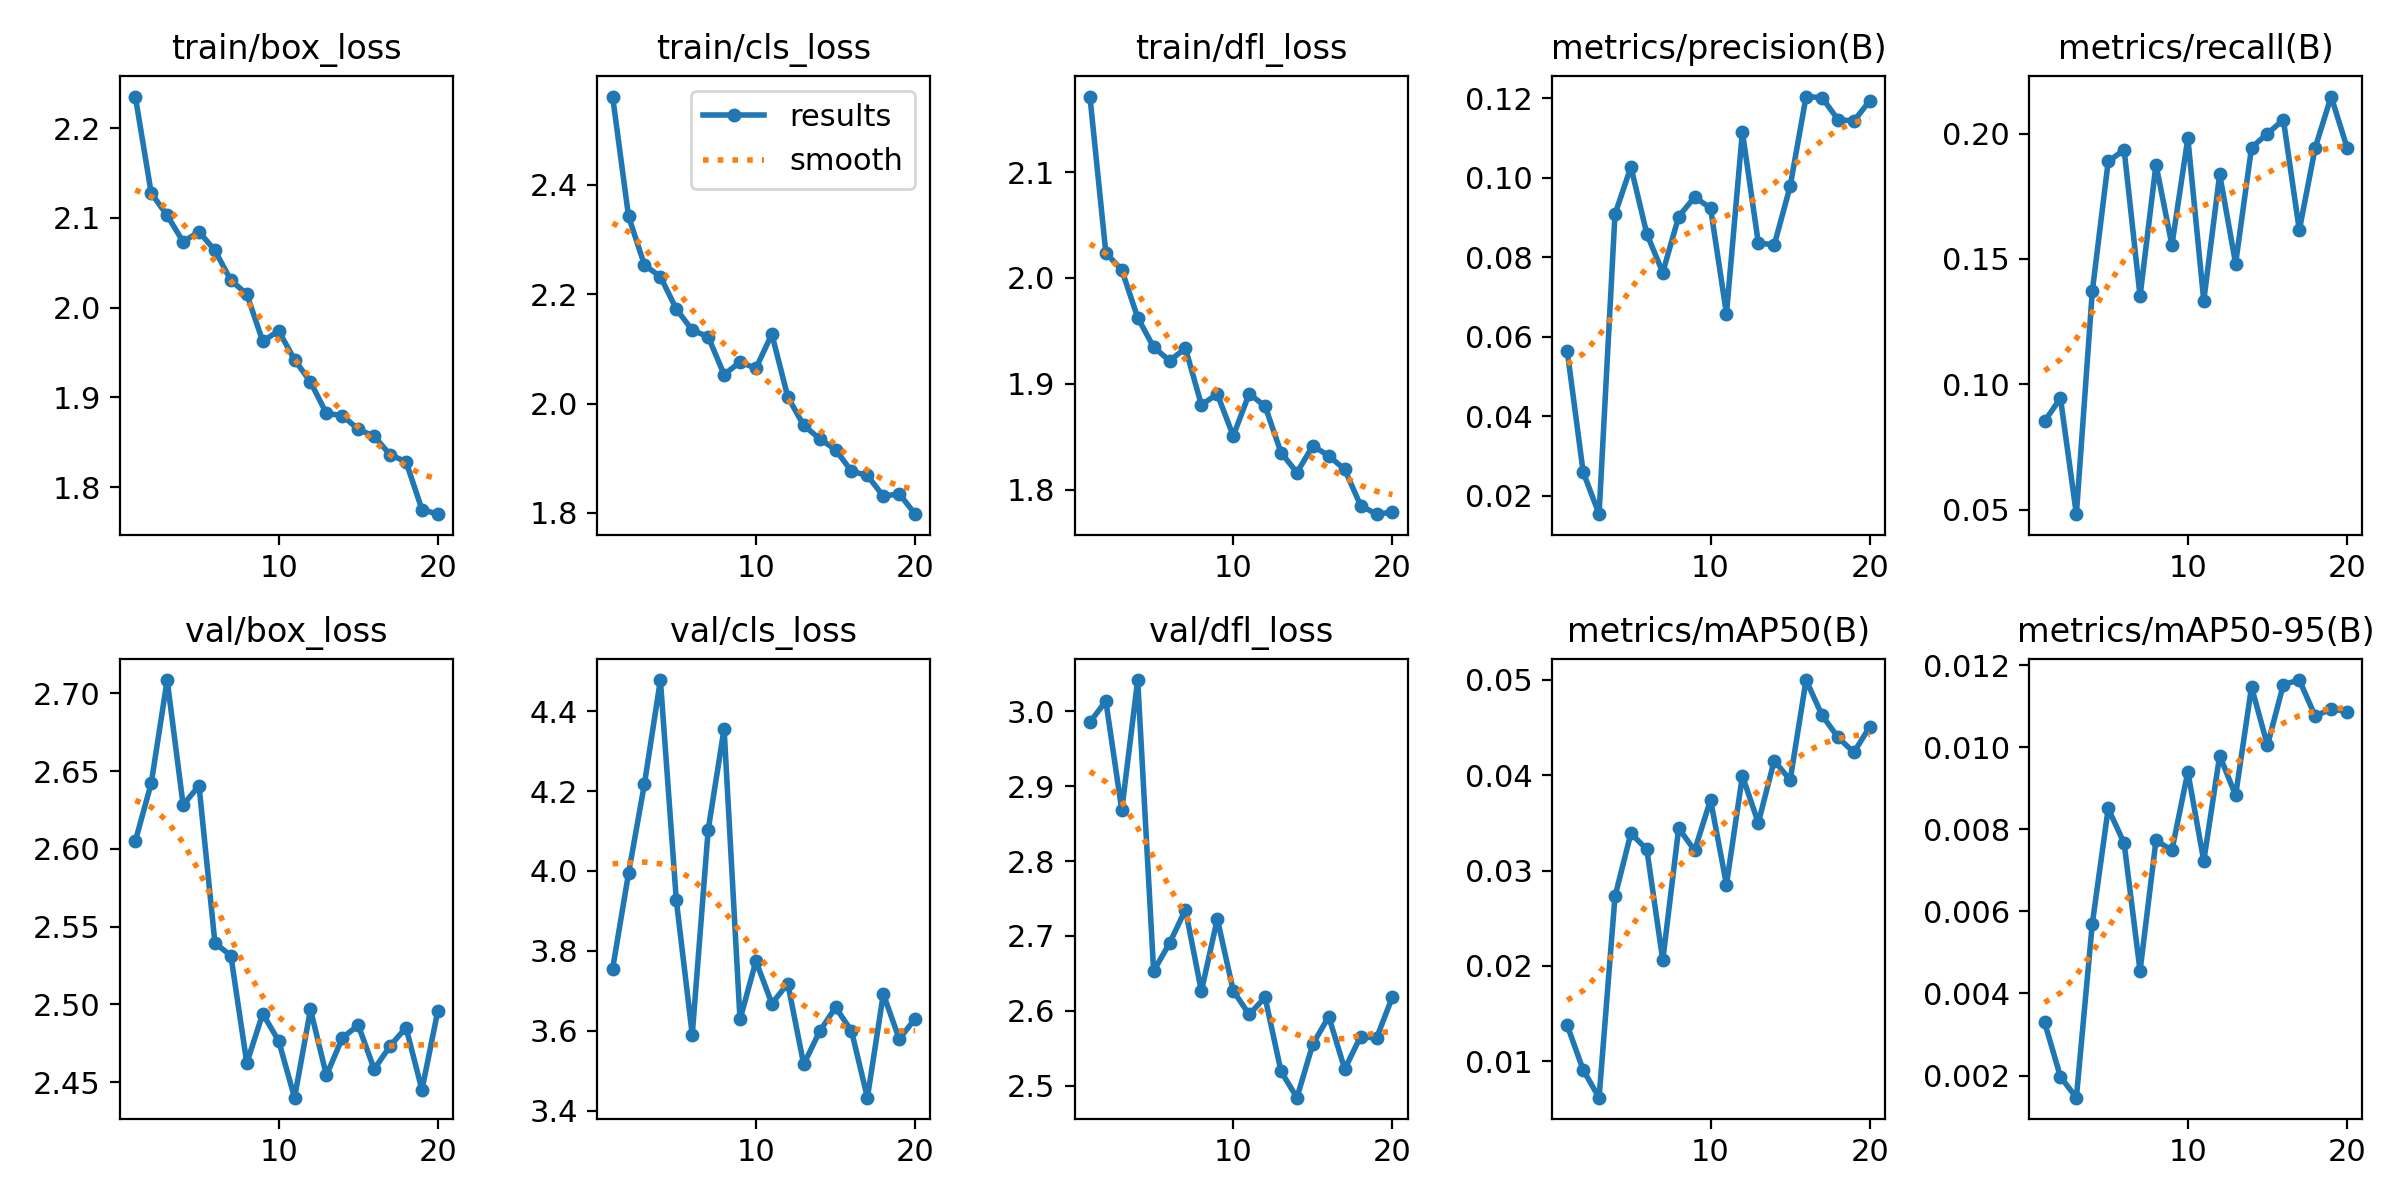

In [ ]:
# 학습 결과 그래프
Image('/content/yolo_runs/pill_detection/results.png')

In [ ]:
# conf 낮추고 실제 저장 경로에서 확인
results = model.predict(
    source='/content/yolo_dataset/images/validation',
    save=True,
    conf=0.1,  # 더 낮춰서 테스트
    verbose=False,
)
print("추론 완료")

WARNING ⚠️ NMS time limit 2.050s exceeded
WARNING ⚠️ NMS time limit 2.050s exceeded


In [ ]:
# 실제 저장된 경로 확인
result_imgs = glob.glob('/content/runs/detect/predict*/*.jpg')
print(f"결과 이미지 수: {len(result_imgs)}")

# 4장 시각화
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, img_path in zip(axes, result_imgs[:4]):
    img = PILImage.open(img_path)
    ax.imshow(img)
    ax.axis('off')
plt.tight_layout()
plt.show()

## 4. 2차 전처리
  - 4.1 Crop + GrayScale + CLAHE

In [ ]:
# validation 이미지 직접 가져오기
val_imgs = glob.glob('/content/yolo_dataset/images/validation/*.png')
print(f"validation 이미지 수: {len(val_imgs)}")

# 1장 추론
result = model.predict(source=val_imgs[0], conf=0.15, verbose=False)[0]
print(f"탐지된 bbox 수: {len(result.boxes)}")
print(f"bbox 좌표:\n{result.boxes.xyxy}")

In [ ]:
# 해당 이미지 파일명 확인
img_name = os.path.basename(val_imgs[0])
print(f"이미지: {img_name}")

# manifest에서 해당 이미지 bbox 수 확인 (정답)
gt_boxes = df[df['image_file'] == img_name]
print(f"실제 알약 수 (정답): {len(gt_boxes)}개")
print(f"모델 탐지 수: {len(result.boxes)}개")

In [ ]:
# 2차 전처리
crops = []
crops_input = []

for box in result.boxes.xyxy:
    x1, y1, x2, y2 = map(int, box.tolist())

    # 1. 1차 전처리 적용 (BGR)
    img_preprocessed = preprocess_common(pil_img)
    img_bgr = (img_preprocessed * 255).astype(np.uint8)

    # 2. crop (BGR 기반)
    crop_bgr = img_bgr[y1:y2, x1:x2]

    # 3. Grayscale 변환
    crop_gray = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2GRAY)

    # 4. CLAHE
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    crop_clahe = clahe.apply(crop_gray)
    crops.append(crop_clahe)

    # 5. 모델 입력 포맷 변환 (1ch → 3ch 복제)
    crop_3ch = cv2.merge([crop_clahe, crop_clahe, crop_clahe])
    crops_input.append(crop_3ch)

print(f"crop 수: {len(crops)}")
print(f"모델 입력 shape: {crops_input[0].shape}")

# 시각화 (원본 crop vs 2차 전처리 결과)
fig, axes = plt.subplots(2, len(crops), figsize=(20, 8))
for i, (box, crop_clahe) in enumerate(zip(result.boxes.xyxy, crops)):
    x1, y1, x2, y2 = map(int, box.tolist())
    crop_orig = np.array(pil_img)[y1:y2, x1:x2]

    axes[0, i].imshow(crop_orig)
    axes[0, i].set_title("원본 crop", fontsize=8)
    axes[0, i].axis('off')

    axes[1, i].imshow(crop_clahe, cmap='gray')
    axes[1, i].set_title("2차 전처리", fontsize=8)
    axes[1, i].axis('off')

plt.suptitle("2차 전처리: 1차전처리 BGR → crop → grayscale → CLAHE")
plt.tight_layout()
plt.show()

## 5. OCR + Classification 병렬 구조
  - 5.1 EasyOCR
  - 5.2 CLIP

In [ ]:
# MySQL 접속
conn = pymysql.connect(
    host='103.218.161.72',   # host
    user='jiwoo_admin',      # user
    password='1234',         # password
    database='pilliot_db',   # database 이름
    port=3306
)

cursor = conn.cursor()

# drug_master 컬럼 목록 확인
cursor.execute("DESCRIBE drug_master;")
columns = cursor.fetchall()
for col in columns:
    print(col)

In [ ]:
# MySQL DB에서 전체 속성 조합 가져오기
cursor.execute("""
    SELECT DISTINCT drug_shape, color_class1, color_class2, form_code_name
    FROM drug_master
    WHERE drug_shape IS NOT NULL
    AND color_class1 IS NOT NULL;
""")
rows = cursor.fetchall()

# CLIP 텍스트 후보 생성
text_candidates = []
for shape, color1, color2, form in rows:
    if color2:
        text = f"{color1} {color2} {shape} {form}"
    else:
        text = f"{color1} {shape} {form}"
    text_candidates.append(text)

print(f"텍스트 후보 수: {len(text_candidates)}")
print(text_candidates[:10])

In [ ]:
shape_map = {
    '원형': 'round', '장방형': 'oblong', '타원형': 'oval',
    '팔각형': 'octagonal', '오각형': 'pentagonal', '사각형': 'square',
    '삼각형': 'triangular', '육각형': 'hexagonal', '기타': 'other'
}

color_map = {
    '하양': 'white', '노랑': 'yellow', '주황': 'orange',
    '분홍': 'pink', '빨강': 'red', '갈색': 'brown',
    '초록': 'green', '연두': 'light green', '파랑': 'blue',
    '보라': 'purple', '청록': 'teal', '검정': 'black', '회색': 'gray'
}

form_map = {
    '나정': 'tablet', '필름코팅정': 'film-coated tablet',
    '당의정': 'sugar-coated tablet', '경질캡슐제, 산제': 'hard capsule',
    '연질캡슐제, 현탁상': 'soft capsule', '장용성필름코팅정': 'enteric tablet',
    '장용성당의정': 'enteric coated tablet'
}

text_candidates = []
for shape, color1, color2, form in rows:
    shape_en = shape_map.get(shape, shape)
    color1_en = color_map.get(color1, color1)
    color2_en = color_map.get(color2, '') if color2 else ''
    form_en = form_map.get(form, form)

    if color2_en:
        text = f"a {color1_en} and {color2_en} {shape_en} {form_en}"
    else:
        text = f"a {color1_en} {shape_en} {form_en}"
    text_candidates.append(text)

print(f"텍스트 후보 수: {len(text_candidates)}")
print(text_candidates[:10])

In [ ]:
!pip install easyocr -q open_clip_torch -q

import open_clip
import easyocr

# CLIP 초기화
clip_model, _, clip_preprocess = open_clip.create_model_and_transforms('ViT-B-32', pretrained='openai')
clip_model = clip_model.cuda().eval()
clip_tokenizer = open_clip.get_tokenizer('ViT-B-32')

# EasyOCR 초기화
reader = easyocr.Reader(['en'], gpu=True, verbose=False)

# 텍스트 토크나이징
text_tokens = clip_tokenizer(text_candidates).cuda()

print("모델 로드 완료")

In [ ]:
results_parallel = []

for i, (crop_gray, crop_3ch) in enumerate(zip(crops, crops_input)):

    # OCR (EasyOCR) - grayscale 1ch
    ocr_result = reader.readtext(crop_gray, detail=0)

    # CLIP (속성 분류) - 3ch RGB
    crop_pil = PILImage.fromarray(crop_3ch)
    clip_input = clip_preprocess(crop_pil).unsqueeze(0).cuda()

    with torch.no_grad():
        image_features = clip_model.encode_image(clip_input)
        text_features = clip_model.encode_text(text_tokens)

        image_features /= image_features.norm(dim=-1, keepdim=True)
        text_features /= text_features.norm(dim=-1, keepdim=True)

        similarity = (image_features @ text_features.T).squeeze(0)
        top_idx = similarity.argmax().item()

    results_parallel.append({
        'pill_idx': i+1,
        'ocr': ocr_result,
        'clip_top1': text_candidates[top_idx],
        'clip_score': similarity[top_idx].item()
    })

# 결과 출력
for r in results_parallel:
    print(f"\n알약 {r['pill_idx']}")
    print(f"  OCR: {r['ocr']}")
    print(f"  CLIP: {r['clip_top1']} (score: {r['clip_score']:.4f})")